In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [2]:
df = pd.read_excel(r"附件/股票客户流失.xlsx")
df

,账户资金（元）,最后一次交易距今时间（天）,上月交易佣金（元）,累计交易佣金（元）,本券商使用时长（年）,是否流失
0,22686.5,297,149.25,2029.85,0,0
1,190055.0,42,284.75,3889.50,2,0
2,29733.5,233,269.25,2108.15,0,1
3,185667.5,44,211.50,3840.75,3,0
4,33648.5,213,353.50,2151.65,0,1
...,...,...,...,...,...,...
7038,199145.0,40,424.00,3990.50,1,0
7039,682661.0,1,516.00,9362.90,5,0
7040,51180.5,167,148.00,2346.45,0,0
7041,47594.0,174,372.00,2306.60,0,1


In [3]:
X = df.drop("是否流失", axis=1)  #将数据集中的特征变量赋值给X，drop()函数用于删除指定的列，axis=1表示按列删除
y = df["是否流失"]  #将数据集中的目标变量赋值给y

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  #使用train_test_split函数将数据集划分为训练集和测试集，test_size参数表示测试集占比，random_state参数表示随机种子

In [5]:
model = LogisticRegression()  #创建逻辑回归模型对象
model.fit(X_train, y_train)  #使用训练集数据对模型进行训练，

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [6]:
y_pred  = model.predict(X_test)  #使用测试集数据对模型进行预测，predict()函数用于对输入数据进行预测，返回预测结果

In [7]:
a = pd.DataFrame({"实际值": y_test, "预测值": y_pred})  #将实际值和预测值放在一个DataFrame中，方便比较
a.head()

,实际值,预测值
185,1,0
2715,0,0
3825,0,0
1807,1,1
132,0,0


In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
accuracy = accuracy_score(y_test, y_pred)  #计算准确率
precision = precision_score(y_test, y_pred)  #计算精确率    
recall = recall_score(y_test, y_pred)  #计算召回率
f1 = f1_score(y_test, y_pred)  #计算F1值
print("准确率：", accuracy)
print("精确率：", precision)  
print("召回率：", recall)
print("F1值：", f1)

准确率： 0.794889992902768
精确率： 0.6666666666666666
召回率： 0.450402144772118
F1值： 0.5376


In [9]:
y_pred_proba = model.predict_proba(X_test) #使用predict_proba()函数获取预测概率，[:, 1]表示获取正类的概率
y_pred_proba[0:5]

array([[0.72178913, 0.27821087],
       [0.951483  , 0.048517  ],
       [0.9643304 , 0.0356696 ],
       [0.20177198, 0.79822802],
       [0.95221713, 0.04778287]])

In [10]:
from sklearn.metrics import confusion_matrix
m = confusion_matrix(y_test,y_pred)
m

array([[952,  84],
       [205, 168]])

In [11]:
a = pd.DataFrame(m,index=['0(实际不流失)','1(实际流失)'],columns=['0[预测不流失]','1(预测流失)'])
a

,0[预测不流失],1(预测流失)
0(实际不流失),952,84
1(实际流失),205,168


In [12]:
# 计算命中率
from sklearn.metrics import classification_report 
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.92      0.87      1036
           1       0.67      0.45      0.54       373

    accuracy                           0.79      1409
   macro avg       0.74      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409



In [13]:
y_pred_proba = model.predict_proba(X_test)


In [14]:
from sklearn.metrics import roc_curve

In [15]:
fpr,tpr,thres = roc_curve(y_test,y_pred_proba[:,1])  #roc_curve函数返回的是一个含有三个元素的数组，其中默认第一个元素为假警报率，第二个元素为命中率，第三个元素为阈值。


In [16]:
a = pd.DataFrame()
a['阈值'] = list(thres)
a['假警报率'] = list(fpr)
a['命中率'] = list(tpr)
a

,阈值,假警报率,命中率
0,inf,0.000000,0.000000
1,0.918064,0.000000,0.002681
2,0.884498,0.000000,0.021448
3,0.882405,0.000965,0.021448
4,0.875780,0.000965,0.032172
...,...,...,...
417,0.044108,0.873552,0.994638
418,0.043936,0.873552,0.997319
419,0.040723,0.889961,0.997319
420,0.040602,0.889961,1.000000


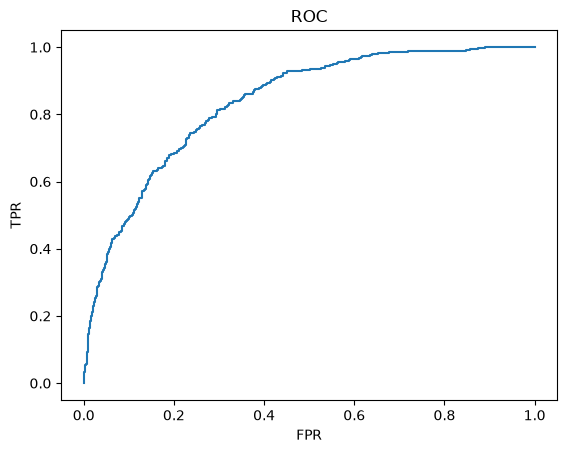

In [17]:
import matplotlib.pyplot as plt
plt.plot(fpr,tpr)
plt.title('ROC')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.show()

In [18]:
from sklearn.metrics import roc_auc_score 
score = roc_auc_score(y_test,y_pred_proba[:,1])
score

0.8354829360191292

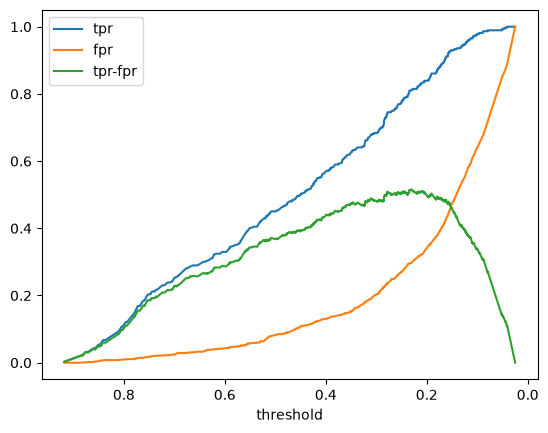

In [19]:
# KS曲线
plt.plot(thres[1:],tpr[1:])
plt.plot(thres[1:],fpr[1:])
plt.plot(thres[1:],(tpr[1:] - fpr[1:]))
plt.xlabel('threshold')
plt.legend(['tpr','fpr','tpr-fpr'])
plt.gca().invert_xaxis()
plt.show()

In [20]:
max(tpr-fpr)

np.float64(0.5160003933462378)

In [21]:
a

,阈值,假警报率,命中率
0,inf,0.000000,0.000000
1,0.918064,0.000000,0.002681
2,0.884498,0.000000,0.021448
3,0.882405,0.000965,0.021448
4,0.875780,0.000965,0.032172
...,...,...,...
417,0.044108,0.873552,0.994638
418,0.043936,0.873552,0.997319
419,0.040723,0.889961,0.997319
420,0.040602,0.889961,1.000000


In [27]:
a['TPR-FPR'] = a['命中率'] - a['假警报率']
a[a['TPR-FPR'] == max(a['TPR-FPR'])]


,阈值,假警报率,命中率,TPR-FPR
294,0.230689,0.296332,0.812332,0.516
